# Haberman's Survival dataset


In [3]:
## Importing
import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import numpy as np
from evclust.utils import plotting, display_results_fuzzy_partition, display_results_evidential
import pandas as pd
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from ucimlrepo import fetch_ucirepo

from evclust.ecm import ecm
from evclust.wecm_new_barycenter import wecm
from evclust.wecm_new_barycenter_2 import wecm as wecm2
from evclust.fcm.fcm_keller2000 import fcm as fcm_keller2000
from evclust.fcm.fcm_wang2004 import fcm as fcm_wang2004
from evclust.fcm.fcm_frigui2004 import scad1
from evclust.fcm.fcm_frigui2004 import scad2
from evclust.fcm.ifwfcm_xing2014 import fcm as ifwfcm_xing2014
from evclust.fcm.ifwfcm_kd_xing2014 import fcm as ifwfcm_kd_xing2014

Instances 306 - Features 3 - Class 2
   age  operation_year  positive_auxillary_nodes
0   30              64                         1
1   30              62                         3
2   30              65                         0
3   31              59                         2
4   31              65                         4


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


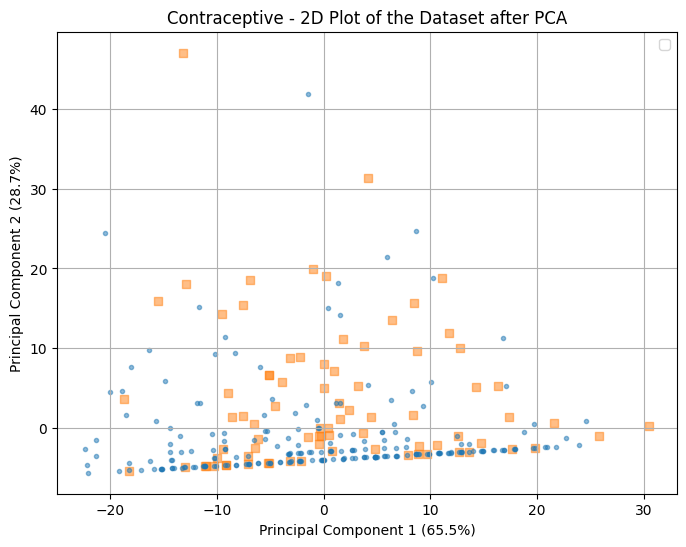

In [4]:

# fetch dataset
df = fetch_ucirepo(id=43)
X = df.data.features
y = df.data.targets

label_column_nm = y.columns[0]
labels_encoder = LabelEncoder()
numeric_labels = labels_encoder.fit_transform(y[label_column_nm])
plotting(X, y, ds_name="Contraceptive", matrix_plot=False)
c = len(np.unique(numeric_labels))

# Normalization
scaler = MinMaxScaler(feature_range=(0, 1))
X = pd.DataFrame(scaler.fit_transform(X))

## Traditional ECM

In [5]:
%%capture
# Traditional ECM clustering
delta = np.sqrt(20)
ecm_models = np.array([])
for i in range(10):
    model = ecm(x=X, c=c, beta=2, alpha=1, delta=delta, init="None", epsi=1e-5)
    ecm_models = np.append(ecm_models, model)

ecm_models = sorted(ecm_models, key=lambda x: x['crit'])

J values: [14.341207556570971, 14.34120795997222, 14.34120798727779, 14.341208277290532, 14.341208330476308, 14.341208344556055, 14.341209014871671, 14.341209691886986, 14.34121000773302, 14.341210198975302]
ARI values: [-0.000460575832125726, -0.000460575832125726, -0.000460575832125726, -0.000460575832125726, -0.000460575832125726, -0.000460575832125726, -0.000460575832125726, -0.000460575832125726, -0.000460575832125726, -0.000460575832125726]
NS values: [1.0588898443574954, 1.0404218027923253, 1.0403884351599004, 1.0404477585999197, 1.0588786075612804, 1.0588587678698074, 1.058979658304442, 1.0403687187992923, 1.0589117747050671, 1.0404360105856694]
NMI values: [0.0021172710203252506, 0.0021172710203252506, 0.0021172710203252506, 0.0021172710203252506, 0.0021172710203252506, 0.0021172710203252506, 0.0021172710203252506, 0.0021172710203252506, 0.0021172710203252506, 0.0021172710203252506]


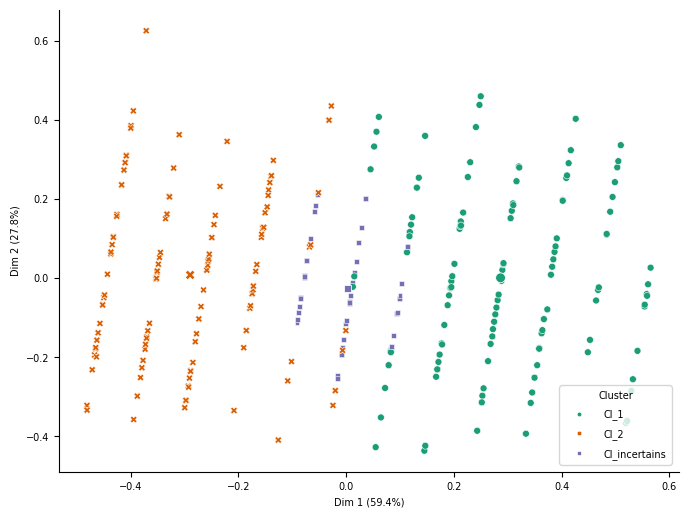

In [6]:
display_results_evidential(X, ecm_models, numeric_labels, up_low_appr=False)

## Weighted ECM (WECM)

In [7]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = wecm(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center")
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.5841130349543785, 0.5841130349543785, 0.5841130349543785, 0.5841130349543785, 0.5841130349543785, 0.5841130349543785, 0.5841130349543787, 0.5841130349543787, 0.5841130349543787, 0.5841130349543787]
ARI values: [0.18676305473080868, 0.18676305473080868, 0.18676305473080868, 0.18676305473080868, 0.18676305473080868, 0.18676305473080868, 0.18676305473080868, 0.18676305473080868, 0.18676305473080868, 0.18676305473080868]
NS values: [0.4970068389565979, 0.4970068389565979, 0.4970068389565979, 0.4970068389565979, 0.4970068389565979, 0.4970068389565979, 1.0339012477132148, 1.0339012477132148, 1.0339012477132148, 1.0339012477132148]
NMI values: [0.08534774203785128, 0.08534774203785128, 0.08534774203785128, 0.08534774203785128, 0.08534774203785128, 0.08534774203785128, 0.08534774203785128, 0.08534774203785128, 0.08534774203785128, 0.08534774203785128]


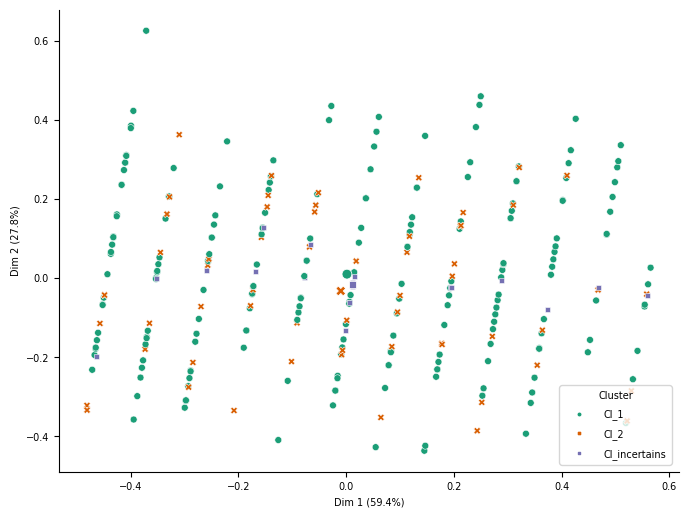

In [8]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

## WECM2

In [9]:
%%capture
wecm_models = np.array([])
d = X.shape[1]
delta = np.sqrt(20)
for i in range(10):
    model = wecm2(x=X, c=c, beta=2, alpha=1, delta=delta, stopping_factor="center", init="None", epsilon=1e-4)
    wecm_models = np.append(wecm_models, model)

wecm_models = sorted(wecm_models, key=lambda model: model['crit'])

J values: [0.7835792970197458, 0.7835831901982405, 0.7836124073546176, 0.7838298693540131, 1.2118217751109421, 1.2408692888098145, 1.2856872378958157, 1.3005360254952196, 1.3177593939628163, 1.412721926482515]
ARI values: [0.1543387411043481, 0.1543387411043481, 0.1543387411043481, 0.1543387411043481, 0.03140787362411653, 0.04445672349171825, -0.0026667177760036375, -0.0027941761668587493, -0.0027753625823600005, 0.0017142898915088424]
NS values: [0.46502894923682403, 1.083289680865712, 0.4701510808562609, 1.0880729595757415, 1.2337810511219547, 1.1264025403041347, 0.9082700997405684, 0.9145299157378038, 0.9226417191135526, 0.9751006452854839]
NMI values: [0.07013624934689801, 0.07013624934689801, 0.07013624934689801, 0.07013624934689801, 0.012344161034924224, 0.014054316486926998, 0.0003591821933139373, 0.00023947240349891637, 2.5345769105906737e-05, 0.003926018981492194]


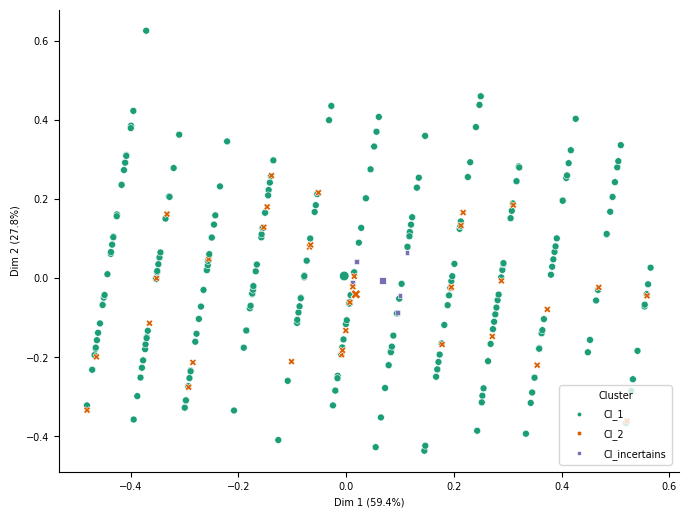

In [10]:
display_results_evidential(X, wecm_models, numeric_labels, up_low_appr=False)

# Weighted FCM - Keller et al. 2000

In [11]:
%%capture
keller_models = np.array([])
w0 = np.ones((c, X.shape[1])) / X.shape[1]
for i in range(10):
    model = fcm_keller2000(X, c=c, w0=w0, verbose=True, epsilon=1e-6)
    keller_models = np.append(keller_models, model)
keller_models = sorted(keller_models, key=lambda model: model['obj_func'])

J values: [0.8088142531473843, 0.8088142531473843, 0.8088142531473843, 0.8088142531473843, 0.8088142531473843, 0.8088142531473843, 0.8088142531473843, 0.8088142531473843, 0.8088142531473843, 0.8088142531473843]
ARI values: [0.16631731751931728, 0.16631731751931728, 0.16631731751931728, 0.16631731751931728, 0.16631731751931728, 0.16631731751931728, 0.16631731751931728, 0.16631731751931728, 0.16631731751931728, 0.16631731751931728]
NMI values: [0.06894569095627709, 0.06894569095627709, 0.06894569095627709, 0.06894569095627709, 0.06894569095627709, 0.06894569095627709, 0.06894569095627709, 0.06894569095627709, 0.06894569095627709, 0.06894569095627709]


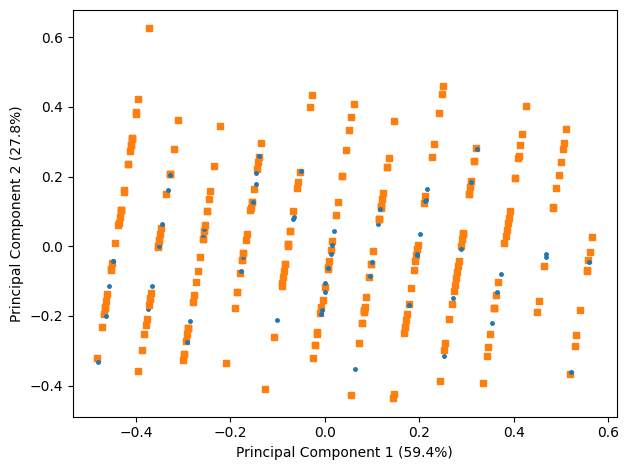

In [12]:
display_results_fuzzy_partition(X, keller_models, numeric_labels)

# Weighted FCM Wang 2004

In [13]:
%%capture
wang_models = np.array([])
for i in range(2):
    model = fcm_wang2004(X, c, w_beta=2.2, verbose=True)
    wang_models = np.append(wang_models, model)
wang_models = sorted(wang_models, key=lambda model: model['obj_func'])

J values: [2.0704017775620898, 2.0704017775620898]
ARI values: [-0.0027753625823600005, -0.0027753625823600005]
NMI values: [0.001988502952838723, 0.001988502952838723]


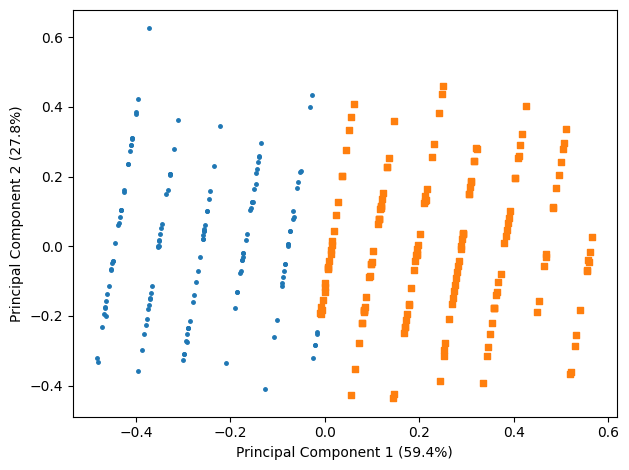

In [14]:
display_results_fuzzy_partition(X, wang_models, numeric_labels)

# SCAD1

In [15]:
%%capture
scad1_models = np.array([])
for i in range(10):
    model = scad1(X, c, verbose=True, K=2, epsilon=1e-6, init="None", stop_factor="Center")
    scad1_models = np.append(scad1_models, model)
scad1_models = sorted(scad1_models, key=lambda model: model['obj_func'])


J values: [17.98205785338936, 17.982057984130215, 17.982058224793928, 17.98205824418835, 17.98205827476458, 17.98205946570036, 17.982059577399095, 17.98205961351236, 17.98205968520928, 17.9820597042022]
ARI values: [-0.001101807536824497, -0.001101807536824497, -0.001101807536824497, -0.001101807536824497, -0.001101807536824497, -0.001101807536824497, -0.001101807536824497, -0.001101807536824497, -0.001101807536824497, -0.001101807536824497]
NMI values: [0.0023770694008368887, 0.0023770694008368887, 0.0023770694008368887, 0.0023770694008368887, 0.0023770694008368887, 0.0023770694008368887, 0.0023770694008368887, 0.0023770694008368887, 0.0023770694008368887, 0.0023770694008368887]


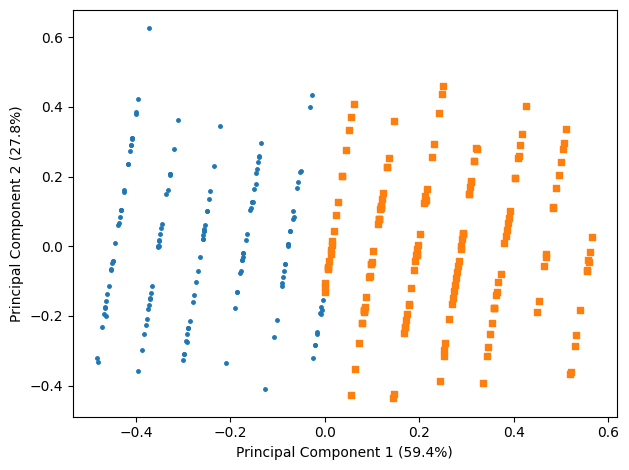

In [16]:
display_results_fuzzy_partition(X, scad1_models, numeric_labels)

# SCAD2

In [17]:
%%capture
scad2_models = np.array([])
for i in range(10):
    model = scad2(X, c, verbose=True, init="None", epsilon=1e-6, stop_factor="center")
    scad2_models = np.append(scad2_models, model)
scad2_models = sorted(scad2_models, key=lambda model: model['obj_func'])


J values: [0.9622831549806827, 0.9622834357532167, 1.7635185243977305, 1.7635185700456577, 1.763518572262703, 1.7635187083434585, 1.7635289941854126, 1.7635290874485174, 1.763529145895072, 1.7635292244381475]
ARI values: [0.1585847418664021, 0.1585847418664021, -0.0024282291686130255, -0.0024282291686130255, -0.0024282291686130255, -0.0024282291686130255, -0.0024282291686130255, -0.0024282291686130255, -0.0024282291686130255, -0.0024282291686130255]
NMI values: [0.07148391711567878, 0.07148391711567878, 3.7562305947171853e-06, 3.7562305947171853e-06, 3.7562305947171853e-06, 3.7562305947171853e-06, 3.7562305947171853e-06, 3.7562305947171853e-06, 3.7562305947171853e-06, 3.7562305947171853e-06]


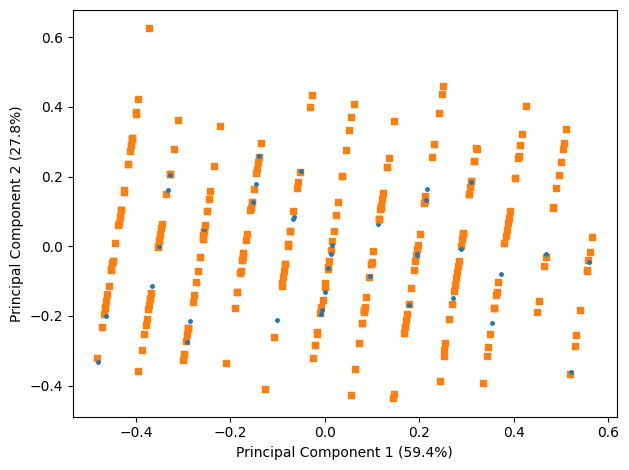

In [18]:
display_results_fuzzy_partition(X, scad2_models, numeric_labels)

# IFWFCM - Xing et al. 2014

In [19]:
%%capture
ifwfcm_models = np.array([])
for i in range(10):
    model = ifwfcm_xing2014(X, c, verbose=True)
    ifwfcm_models = np.append(ifwfcm_models, model)
ifwfcm_models = sorted(ifwfcm_models, key=lambda model: model['obj_func'])

J values: [1.6691722088961736, 1.6691722088961736, 1.6691722088961736, 1.6691722088961738, 1.6691722088961738, 1.6691722088961738, 1.6691722088961738, 1.6691722088961738, 1.6691722088961738, 1.6691722088961738]
ARI values: [-0.0038715525911809856, -0.0038715525911809856, -0.0038715525911809856, -0.0038715525911809856, -0.0038715525911809856, -0.0038715525911809856, -0.0038715525911809856, -0.0038715525911809856, -0.0038715525911809856, -0.0038715525911809856]
NMI values: [0.0009425007432221527, 0.0009425007432221527, 0.0009425007432221527, 0.0009425007432221527, 0.0009425007432221527, 0.0009425007432221527, 0.0009425007432221527, 0.0009425007432221527, 0.0009425007432221527, 0.0009425007432221527]


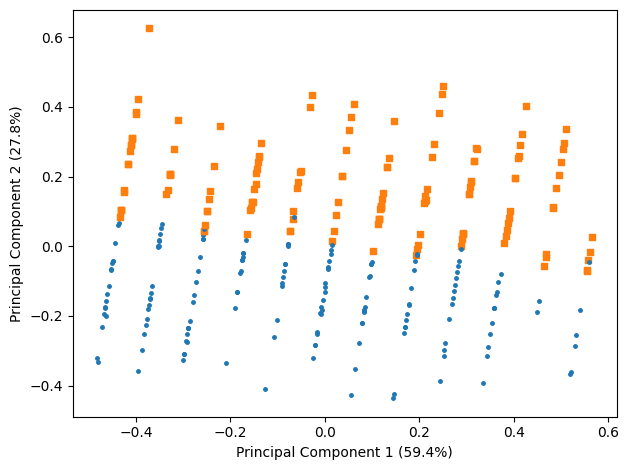

In [20]:
display_results_fuzzy_partition(X, ifwfcm_models, numeric_labels)

# IFWFCM_KD Xing 2014

In [21]:
%%capture
ifwfcm_kd_models = np.array([])
for i in range(10):
    model = ifwfcm_kd_xing2014(X, c, verbose=True, epsilon=1e-6)
    ifwfcm_kd_models = np.append(ifwfcm_kd_models, model)
ifwfcm_kd_models = sorted(ifwfcm_kd_models, key=lambda model: model['obj_func'])

J values: [11.538751766404086, 11.538751766404086, 11.538751766404086, 11.538751766404086, 11.538751766404086, 11.538751766404086, 11.538751766404086, 11.538751766404086, 11.538751766404086, 11.538751766404086]
ARI values: [0.18175988751874259, 0.18175988751874259, 0.18175988751874259, 0.18175988751874259, 0.18175988751874259, 0.18175988751874259, 0.18175988751874259, 0.18175988751874259, 0.18175988751874259, 0.18175988751874259]
NMI values: [0.08085403231156224, 0.08085403231156224, 0.08085403231156224, 0.08085403231156224, 0.08085403231156224, 0.08085403231156224, 0.08085403231156224, 0.08085403231156224, 0.08085403231156224, 0.08085403231156224]


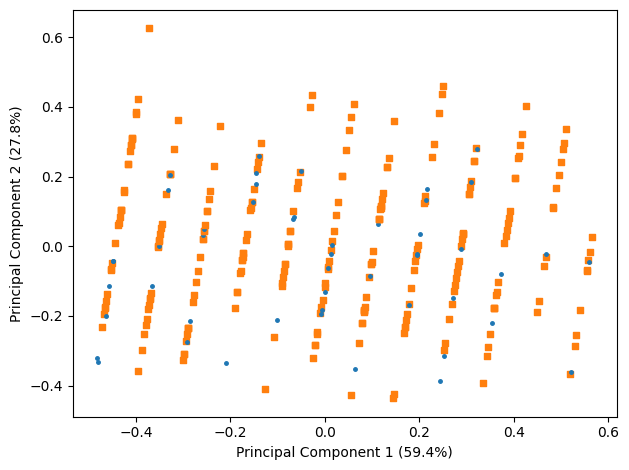

In [22]:
display_results_fuzzy_partition(X, ifwfcm_kd_models, numeric_labels)